# Mantenimiento Predictivo - Análisis Exploratorio de Datos (EDA)

Este notebook realiza el análisis exploratorio del **NASA C-MAPSS Turbofan Dataset**, con el objetivo de entender los datos de los sensores antes de entrenar nuestros modelos de Machine Learning.

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Añadir el directorio raíz al path para importar nuestros módulos
root_dir = Path.cwd().parent
sys.path.append(str(root_dir))

from ml.src.data.data_loader import load_dataset, add_rul_column

# Configuraciones de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
pd.set_option('display.max_columns', 30)

## 1. Carga de Datos
Cargamos el subdataset **FD001** (Condiciones de operación: 1, Condiciones de falla: 1 - HPC Degradation).

In [2]:
data_path = root_dir / 'data' / 'raw'
dataset = load_dataset(data_path, 'FD001')

train_df = dataset['train']
train_df = add_rul_column(train_df)

print(f"Dimensiones del dataset de entrenamiento: {train_df.shape}")
train_df.head()

Dimensiones del dataset de entrenamiento: (20631, 27)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


## 2. Análisis del RUL (Remaining Useful Life)
Veamos cómo se distribuye el RUL máximo para cada motor en el dataset.

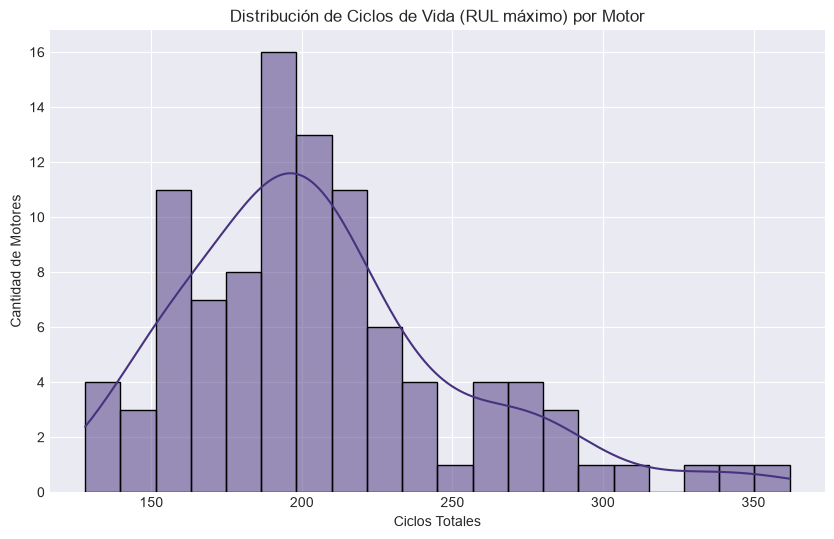

In [3]:
max_rul = train_df.groupby('engine_id')['cycle'].max()

plt.figure(figsize=(10, 6))
sns.histplot(max_rul, bins=20, kde=True)
plt.title('Distribución de Ciclos de Vida (RUL máximo) por Motor')
plt.xlabel('Ciclos Totales')
plt.ylabel('Cantidad de Motores')
plt.show()

## 3. Comportamiento de Sensores vs RUL
Vamos a graficar algunos sensores de un motor específico para ver cómo cambian a medida que el motor se degrada (el RUL se acerca a 0).

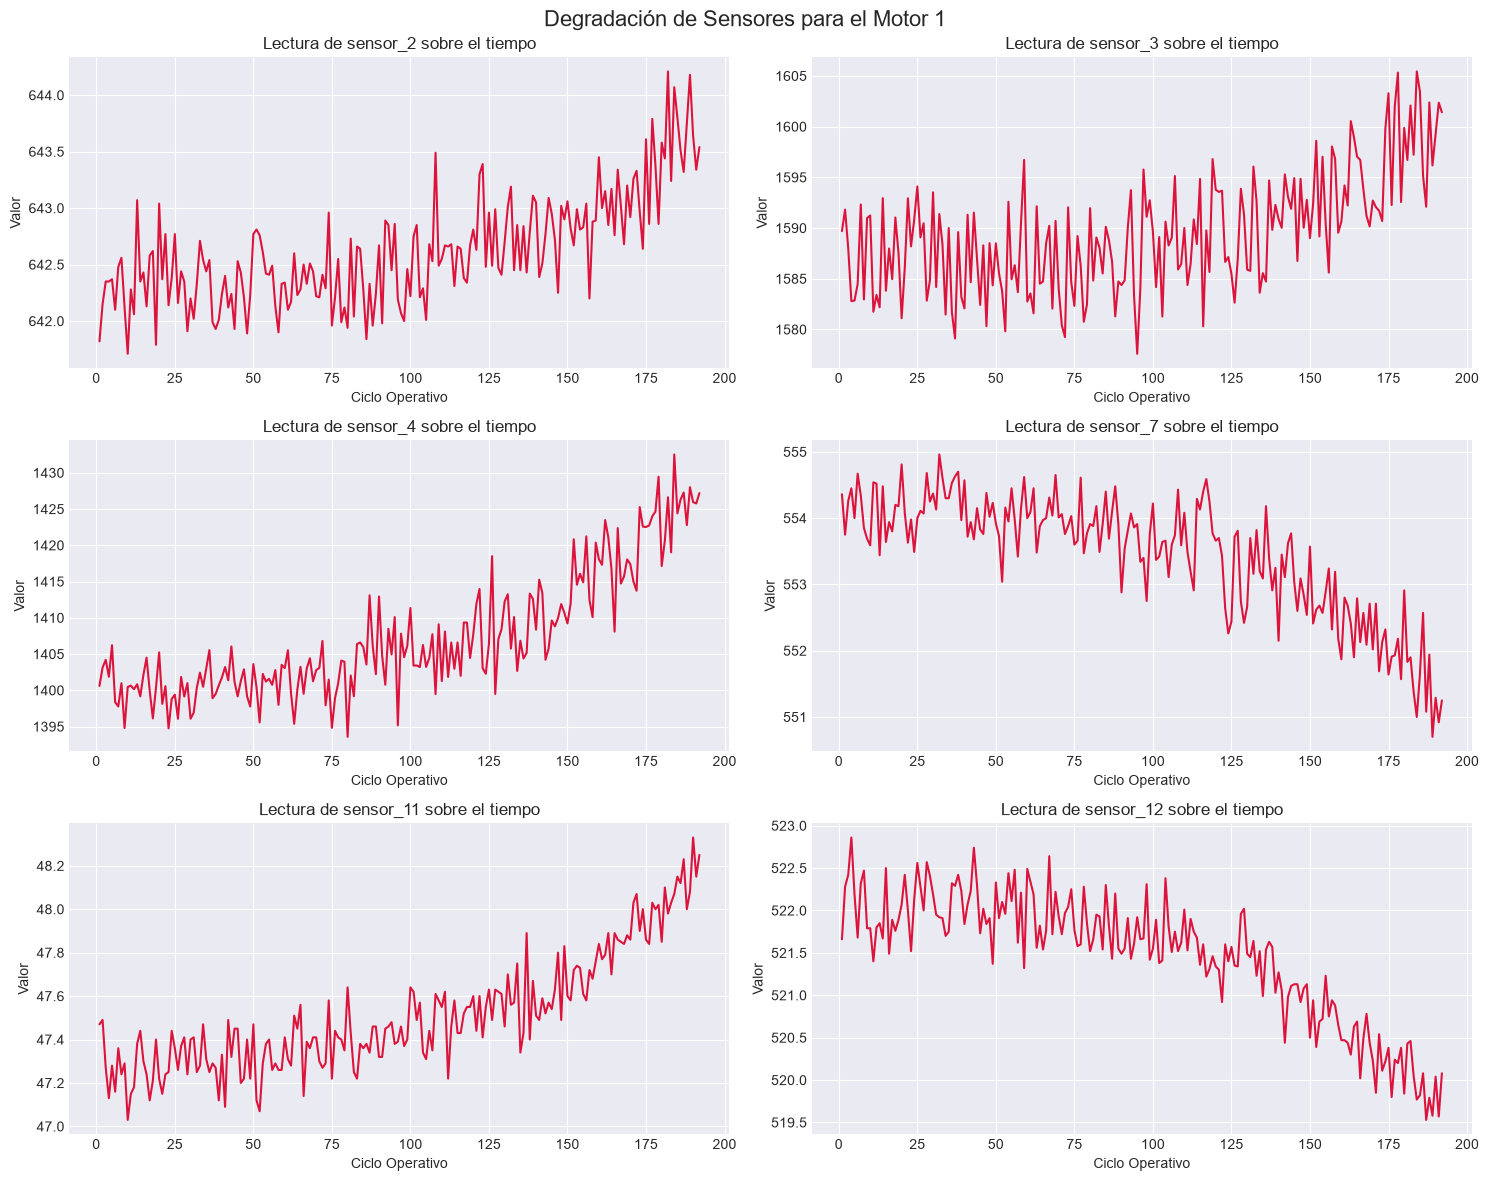

In [4]:
engine_1 = train_df[train_df['engine_id'] == 1]

sensors_to_plot = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12']

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Degradación de Sensores para el Motor 1', fontsize=16)
axes = axes.flatten()

for i, sensor in enumerate(sensors_to_plot):
    sns.lineplot(data=engine_1, x='cycle', y=sensor, ax=axes[i], color='crimson')
    axes[i].set_title(f'Lectura de {sensor} sobre el tiempo')
    axes[i].set_xlabel('Ciclo Operativo')
    axes[i].set_ylabel('Valor')

plt.tight_layout()
plt.show()